## RFM 기반 데이터 가공
- 이 데이터는 거래 데이터가 아니라 행동 데이터라서 클래식 RFM(구매 기반)이 아니라 Engagement-based RFM으로 만들고, Engagement 컬럼을 추가하였다.

|컬럼명|사용 컬럼|의미|
|---|---|---|
|activity_score|notifications_clicked|사용자의 알림 클릭 횟수를 기반으로 한 최근 활동 수준 지표.|
|adjusted_frequency|weekly_songs_played * (1 - song_skip_rate)|노래 재생 횟수에 스킵 비율을 반영한 실제 콘텐츠 소비 빈도 지표.|
|Monetary|weekly_hours|주간 청취 시간을 기반으로 한 서비스 이용 가치 지표.|
|Engagement|num_playlists_created + num_platform_friends + num_shared_friends|플레이리스트 생성, 친구 추가, 공유 활동을 합산한 플랫폼 참여도 지표.|
|subscription_risk |num_subscription_pauses|구독 일시정지 횟수를 기반으로 한 사용자 이탈 위험 신호 지표.|
|support_pressure|customer_service_inquiries|고객센터 문의 횟수를 기반으로 한 서비스 불만 또는 문제 경험 지표.|

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# new rfm_df

In [42]:
model_df = pd.read_csv("data/model_df.csv")
model_df

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome,tenure_days
0,32,Montana,Free,Yearly,2,Paypal,Medium,22.391362,1.756575,0.176873,169,109,18,32,52,35,46,0,47631.156827,1606
1,64,New Jersey,Free,Monthly,3,Paypal,Low,29.294210,0.875019,0.981811,55,55,44,33,12,25,37,1,76533.296517,2897
2,51,Washington,Premium,Yearly,2,Credit Card,High,15.400312,0.411728,0.048411,244,117,20,129,50,28,38,0,64452.058299,348
3,63,California,Family,Yearly,4,Apple Pay,Medium,22.842084,1.393258,0.035691,442,252,47,120,55,17,24,0,67180.181705,2894
4,54,Washington,Family,Monthly,3,Paypal,High,23.151163,0.876304,0.039738,243,230,41,66,40,32,47,0,64452.058299,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,32,California,Student,Monthly,4,Debit Card,Low,29.161399,0.119612,0.893839,460,22,18,199,71,41,41,0,67180.181705,1895
124996,56,Maine,Premium,Yearly,2,Debit Card,Low,44.744198,1.751156,0.668759,315,16,48,185,67,23,30,0,49140.932961,2778
124997,45,Maine,Family,Monthly,0,Paypal,Medium,15.200073,1.301067,0.286604,11,11,48,40,78,40,28,0,49140.932961,604
124998,69,Maine,Free,Monthly,4,Paypal,High,35.270053,0.348684,0.092528,451,108,15,41,3,35,9,1,49140.932961,2570


In [43]:
rfm_df = model_df.assign(
    activity_score = model_df["notifications_clicked"],
    adjusted_frequency = model_df["weekly_songs_played"] * (1 - model_df["song_skip_rate"]),
    Monetary = model_df["weekly_hours"],
    Engagement = (
        model_df["num_playlists_created"] +
        model_df["num_platform_friends"] +
        model_df["num_shared_playlists"]
    ),
    subscription_risk = model_df["num_subscription_pauses"],
    support_pressure = model_df["customer_service_inquiries"]
)[[
    "activity_score",
    "adjusted_frequency",
    "Monetary",
    "Engagement",
    "subscription_risk",
    "support_pressure"
]]
rfm_df

,activity_score,adjusted_frequency,Monetary,Engagement,subscription_risk,support_pressure
0,46,139.108484,22.391362,119,2,Medium
1,37,1.000403,29.294210,70,3,Low
2,38,232.187706,15.400312,207,2,High
3,24,426.224473,22.842084,192,4,Medium
4,47,233.343691,23.151163,138,3,High
...,...,...,...,...,...,...
124995,41,48.833931,29.161399,311,4,Low
124996,30,104.340966,44.744198,275,2,Low
124997,28,7.847359,15.200073,158,0,Medium
124998,9,409.269716,35.270053,79,4,High


In [44]:
# 숫자형 인코딩
rfm_df.info()

mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
}

rfm_df['support_pressure'] = rfm_df['support_pressure'].map(mapping)

rfm_df

<class 'pandas.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   activity_score      125000 non-null  int64  
 1   adjusted_frequency  125000 non-null  float64
 2   Monetary            125000 non-null  float64
 3   Engagement          125000 non-null  int64  
 4   subscription_risk   125000 non-null  int64  
 5   support_pressure    125000 non-null  str    
dtypes: float64(2), int64(3), str(1)
memory usage: 5.7 MB


,activity_score,adjusted_frequency,Monetary,Engagement,subscription_risk,support_pressure
0,46,139.108484,22.391362,119,2,1
1,37,1.000403,29.294210,70,3,0
2,38,232.187706,15.400312,207,2,2
3,24,426.224473,22.842084,192,4,1
4,47,233.343691,23.151163,138,3,2
...,...,...,...,...,...,...
124995,41,48.833931,29.161399,311,4,0
124996,30,104.340966,44.744198,275,2,0
124997,28,7.847359,15.200073,158,0,1
124998,9,409.269716,35.270053,79,4,2


In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

rfm_scaled_df = scaler.fit_transform(rfm_df)
rfm_scaled_df = pd.DataFrame(rfm_scaled_df, columns=rfm_df.columns, index=rfm_df.index)
rfm_scaled_df

,activity_score,adjusted_frequency,Monetary,Engagement,subscription_risk,support_pressure
0,1.494381,0.125060,-0.183121,-0.828193,0.006249,0.002839
1,0.870369,-1.129199,0.294670,-1.569739,0.711868,-1.221010
2,0.939704,0.970380,-0.667016,0.503562,0.006249,1.226689
3,-0.030982,2.732568,-0.151923,0.276558,1.417487,0.002839
4,1.563716,0.980878,-0.130530,-0.540655,0.711868,1.226689
...,...,...,...,...,...,...
124995,1.147708,-0.694788,0.285477,2.077455,1.417487,-1.221010
124996,0.385026,-0.190689,1.364064,1.532646,0.006249,-1.221010
124997,0.246357,-1.067017,-0.680876,-0.237983,-1.404989,0.002839
124998,-1.071003,2.578589,0.708297,-1.433536,1.417487,1.226689


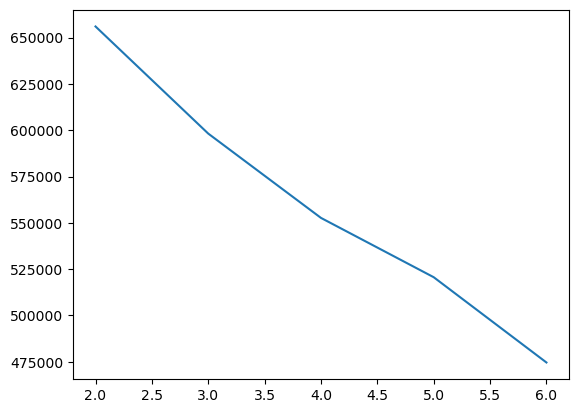

In [36]:
# 적절한 개수의 군집 찾기
# 1) inertia를 활용한 elbow method 방식으로 k 선정

from sklearn.cluster import KMeans

# inertia를 활용한 elbow method 방식으로 k 선정
inertia = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df)

    inertia.append(kmeans.inertia_)

plt.plot(range(2, 7), inertia)
plt.show()

# 특히 많이 꺾어진 부분은 없어서 실루엣 계수와 함께 비교 후 군집 개수 정할 예정

In [ ]:
# # 2) silhouette score
# # 군집이 충분히 분리되어 있지 않은 샘플의 경우에는 실루엣 계수가 크게 도움이 되지 않는다.
# # ⚠️ 실행 시간이 약 13분이 걸리니 주의!!!!
# # 만약 실행하였다면 결과가 나올 때까지 기다려주세요...
# from sklearn.metrics import silhouette_score
#
# sil_score = []
#
# for k in range(2, 7):
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     labels = kmeans.fit_predict(rfm_scaled_df)
#     sil_score.append(silhouette_score(rfm_scaled_df, labels))
#
# plt.plot(range(2, 7), sil_score)
# plt.show()

In [27]:
# 2) 군집화 후에 실루엣 계수 및 군집을 시각화
# 각 군집의 데이터만큼 y축으로 올라간 뒤 내림차순으로 각 군집의 실루엣 스코어를 출력해줌.
import matplotlib.cm as cm      # 색칠하는 역할
from sklearn.metrics import silhouette_samples, silhouette_score

def visualize_silhouette(n_clusters_list, X_features):
    """
    다양한 클러스터 개수에 대해 KMeans 클러스터링을 수행하고,
    각 클러스터링 결과의 실루엣 계수를 시각화하는 함수.

    Parameters:
    - n_clusters_list : 클러스터 개수 리스트 (예: [2, 3, 4])
    - X_features : 클러스터링에 사용할 특성 데이터 (numpy 배열 또는 DataFrame)
    """
    n_cols = len(n_clusters_list)  # 서브플롯 열 개수

    # 서브플롯 생성 (1행, n_cols열)
    fig, axs = plt.subplots(nrows=1, ncols=n_cols, figsize=(4 * n_cols, 4))     # 가로가 넓어지게 figsize 설정.

    # axs가 1개일 경우 리스트 형태로 변환 (for문에서 인덱싱을 위함)
    if n_cols == 1:
        axs = [axs]     # for문 돌 때 indexing을 하는 부분이 있어서 경우의 수가 한 개여도 리스트로 변환해줌.

    for idx, n_clusters in enumerate(n_clusters_list):

        # KMeans 클러스터링 수행
        kmeans = KMeans(n_clusters=n_clusters, max_iter=500, random_state=0)
        cluster_labels = kmeans.fit_predict(X_features)

        # 전체 평균 실루엣 점수와 각 샘플의 실루엣 계수 계산
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        # 시각화 초기 설정
        ax = axs[idx]
        ax.set_title(f'Number of Clusters: {n_clusters}\nSilhouette Score: {round(sil_avg, 3)}')
        ax.set_xlim([-0.1, 1])
        ax.set_ylim([0, len(X_features) + (n_clusters + 1) * 10]) # y축(데이터포인트 개수) + margin을 위한 패딩 설정
        ax.set_xlabel("Silhouette coefficient values")
        ax.set_ylabel("Cluster label")
        ax.set_yticks([])  # Y축 눈금 제거
        ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        y_lower = 10  # 막대 시작 위치 초기화

        for i in range(n_clusters):

            # 현재 클러스터에 속한 샘플들의 실루엣 계수 추출 및 정렬
            ith_cluster_sil_values = sil_values[cluster_labels == i]
            ith_cluster_sil_values.sort()

            # 막대 그릴 y 위치 계산
            size_cluster_i = ith_cluster_sil_values.shape[0] # 데이터샘플수.
            y_upper = y_lower + size_cluster_i

            # 색상 설정 및 막대 시각화
            color = cm.nipy_spectral(float(i) / n_clusters) # 클러스터마다 다른 색을 자동으로 지정
            # fill_betweenx(y, x1, x2) : y축 위에 있는 두 개의 선(x1, x2) 사이에 색칠된 영역을 만듦
            # - y와 x1, x2가 모두 같은 길이여야 한다. (scala인 경우 broadcasting 가능)
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                             facecolor=color, edgecolor=color, alpha=0.7)       # 0부터 실루엣 스코어까지의 길이만큼 색칠하라는 뜻.

            # 클러스터 번호 표시
            # - x좌표: 0보다 왼쪽
            # - y좌표: 높이의 중간
            ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # 다음 막대 시작 위치 업데이트
            y_lower = y_upper + 10

        # 전체 실루엣 평균값 수직선 표시
        ax.axvline(x=sil_avg, color="red", linestyle="--")      # 각 경우의 실루엣 계수를 세로로 그려줌.

    plt.tight_layout()
    plt.show()


In [28]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 3) 군집 시각화
def visualize_kmeans_cluster(n_clusters_list, X_features):
    """
    다양한 클러스터 수에 대해 KMeans 클러스터링을 수행하고,
    PCA로 2차원 변환한 결과를 시각화하는 함수.

    Parameters:
    - n_clusters_list : 클러스터 개수 리스트 (예: [2, 3, 4])
    - X_features : 클러스터링에 사용할 입력 데이터 (2차원 배열 또는 DataFrame)
    """
    n_cols = len(n_clusters_list)  # subplot 열 수
    fig, axs = plt.subplots(nrows=1, ncols=n_cols, figsize=(4 * n_cols, 4))

    # axs가 하나일 경우 리스트 형태로 변환 (인덱싱 편의 위해)
    if n_cols == 1:
        axs = [axs]

    # PCA로 입력 데이터를 2차원으로 변환
    pca = PCA(n_components=2)       # 원활한 시각화를 위해 2차원으로 줄임.
    pca_transformed = pca.fit_transform(X_features)
    base_df = pd.DataFrame(pca_transformed, columns=['PCA1', 'PCA2'])

    # 클러스터 수를 바꿔가며 클러스터링과 시각화 반복
    for idx, n_clusters in enumerate(n_clusters_list):
        # KMeans 클러스터링 수행
        kmeans = KMeans(n_clusters=n_clusters, max_iter=500, random_state=0)
        cluster_labels = kmeans.fit_predict(pca_transformed)

        # 클러스터 결과를 복사본에 저장 (base_df를 매번 복사)
        df = base_df.copy()
        df['cluster'] = cluster_labels

        # 클러스터 라벨별로 시각화
        ax = axs[idx]
        unique_labels = np.unique(cluster_labels)
        markers = ['o', 's', '^', 'd', '*', 'D', 'v']  # 7개까지 지원

        for label in unique_labels:     # 클러스터의 종류만큼 돌면서 scatter 출력
            cluster_data = df[df['cluster'] == label]
            marker = markers[label % len(markers)]  # 마커 수 초과 대비. 클러스터의 수가 마커수보다 많을 경우 다시 순회하도록 함.
            cluster_name = f"Cluster {label}"

            ax.scatter(cluster_data['PCA1'], cluster_data['PCA2'],
                       s=70, edgecolor='k', marker=marker, label=cluster_name)

        ax.set_title(f'Number of Clusters: {n_clusters}')
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


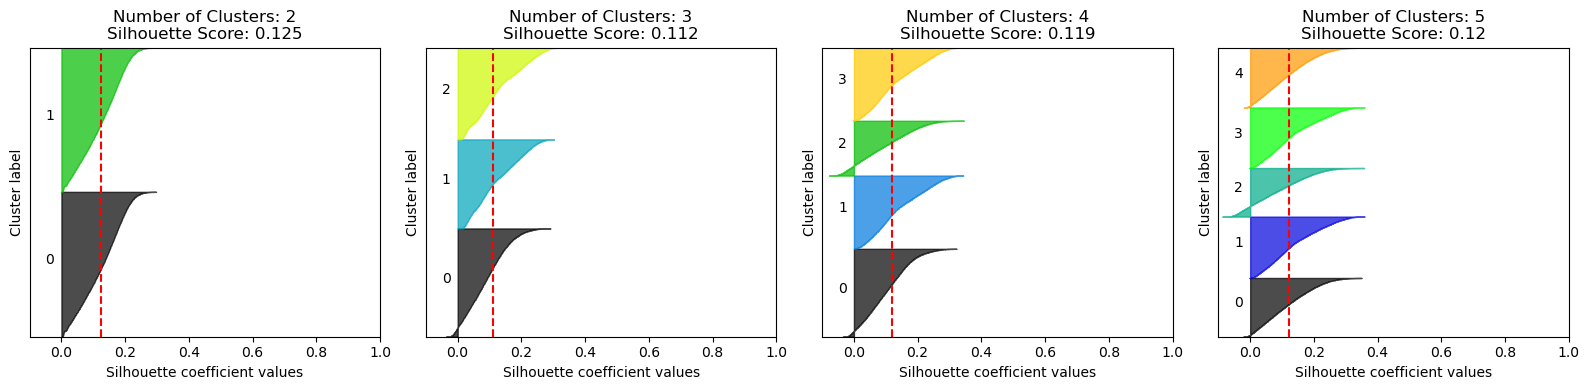

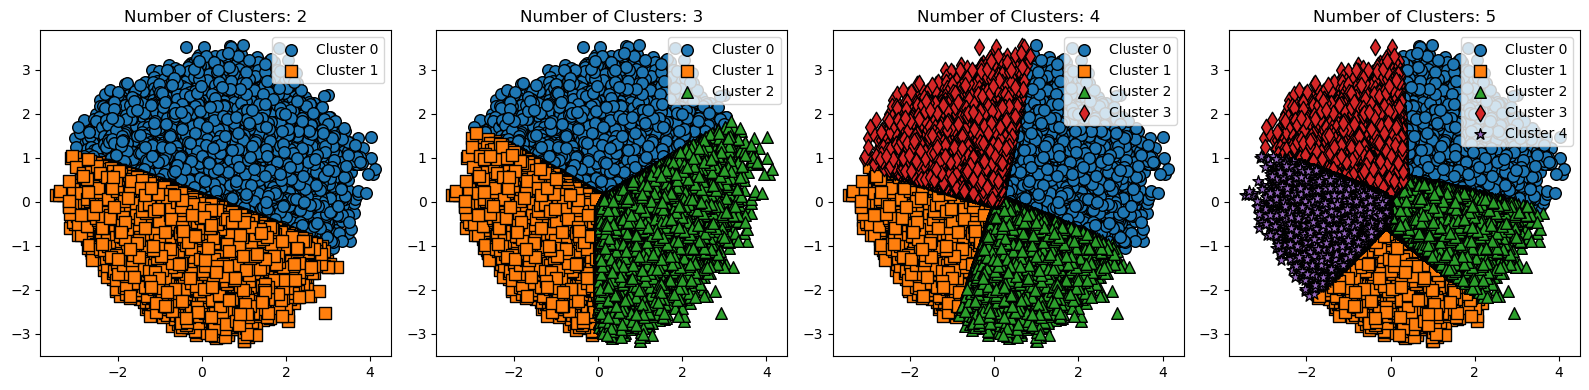

In [29]:
# ⚠️실행 시간 20분 넘음!!!! 실행할 때 주의 요망!!! ⚠️
# 혹시 실행했다면 그대로 놔두면 됩니다...
visualize_silhouette([2, 3, 4, 5], rfm_scaled_df)
visualize_kmeans_cluster([2, 3, 4, 5], rfm_scaled_df)

# silhouette 계수를 시각화 했을 때, 각 군집에 데이터가 넉넉하게 들어있다는 것을 알 수 있다.
# 실루엣 계수를 보고 각 클러스터(군집)별 데이터가 고루 분포되어 있는 것을 기준으로 k값을 고민하자. 고객 분포는 k값이 클수록 좋다.

In [46]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(rfm_scaled_df)

rfm_df['cluster'] = labels
rfm_df

,activity_score,adjusted_frequency,Monetary,Engagement,subscription_risk,support_pressure,cluster
0,46,139.108484,22.391362,119,2,1,3
1,37,1.000403,29.294210,70,3,0,3
2,38,232.187706,15.400312,207,2,2,3
3,24,426.224473,22.842084,192,4,1,1
4,47,233.343691,23.151163,138,3,2,3
...,...,...,...,...,...,...,...
124995,41,48.833931,29.161399,311,4,0,3
124996,30,104.340966,44.744198,275,2,0,2
124997,28,7.847359,15.200073,158,0,1,0
124998,9,409.269716,35.270053,79,4,2,1


## 클러스터링 한 고객 정보를 기반으로 분석 진행

### 1. 각 군집별 고객 수 도출
- 4가지 유형에 고르게 분포되어 있음.
- 데이터 편향이 없음. 세그먼트가 균형 있게 존재.

In [51]:
rfm_df['cluster'].value_counts()

cluster
0    31410
3    31388
2    31243
1    30959
Name: count, dtype: int64

### 2. 간단한 분석

In [52]:
# 각 군집별 요약본
rfm_df.groupby('cluster').mean().T

cluster,0,1,2,3
activity_score,23.696307,10.835912,24.988189,38.083981
adjusted_frequency,127.954187,123.302717,125.029824,125.033974
Monetary,11.321542,25.992302,38.569571,24.349710
Engagement,177.666285,175.953810,169.192395,172.096311
subscription_risk,0.827857,3.166834,0.818967,3.162387
support_pressure,0.998758,1.014665,0.977275,1.000159


<Axes: ylabel='cluster'>

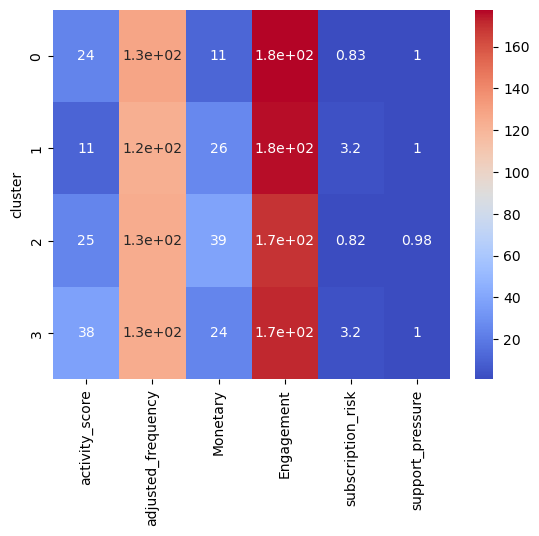

In [53]:
# 시각화
import seaborn as sns
sns.heatmap(rfm_df.groupby('cluster').mean(), annot=True, cmap="coolwarm")

## 4. 클러스터 결과를 기반으로 한 페르소나 분석 + 대응 전략

### 클러스터별 사용자 유형 정의

| Cluster | 유형              | 특징                   |
| ------- | --------------- | -------------------- |
| 0       | 일반 활성 사용자       | 콘텐츠 소비 많고 안정적        |
| 1       | 활동 감소 이탈 위험 사용자 | activity 낮고 pause 많음 |
| 2       | 핵심 헤비 사용자       | 청취 시간 가장 많음          |
| 3       | 활동 높지만 불만 사용자   | activity 높지만 risk 높음 |


### Cluster 0 — 안정적 콘텐츠 소비형 사용자 (Stable Listeners)

#### 페르소나
이 사용자 그룹은 콘텐츠 소비 빈도가 높고 플랫폼 참여도도 비교적 높은 **안정적인 일반 활성 사용자**이다.
서비스를 꾸준히 사용하며 콘텐츠를 소비하지만, 청취 시간이나 활동 수준이 극단적으로 높은 헤비 유저는 아니다.
구독 중단 위험이 낮아 비교적 안정적인 사용자군으로 볼 수 있다.

#### 주요 특징
- 콘텐츠 소비 빈도 높음
- 플랫폼 기능 참여도 높음
- 이탈 위험 낮음
- 서비스 사용 패턴이 안정적

#### 대응 전략
- 개인화 추천 플레이리스트 강화
- 신규 음악 및 아티스트 추천
- 친구 공유 및 소셜 기능 활성화
- 사용자 참여를 유도하는 이벤트 제공

### Cluster 1 — 활동 감소형 이탈 위험 사용자 (At-Risk Users)

#### 페르소나
이 그룹은 최근 활동 수준이 낮고 구독 일시정지 경험이 많은 **이탈 위험 사용자**이다.
플랫폼 참여도는 일정 수준 유지되지만 서비스 사용 빈도가 감소하고 있으며, 장기적으로 서비스 이탈 가능성이 높은 사용자군이다.

#### 주요 특징
- 활동 수준 낮음
- 구독 일시정지 경험 많음
- 콘텐츠 소비 감소 추세
- 서비스 이탈 가능성 존재

#### 대응 전략
- 재참여 유도를 위한 개인화 알림 발송
- 할인 프로모션 및 구독 유지 혜택 제공
- 관심 콘텐츠 기반 추천 강화
- 복귀 유도 캠페인 진행

### Cluster 2 — 핵심 헤비 콘텐츠 소비자 (Power Listeners)

#### 페르소나
이 그룹은 청취 시간이 가장 높은 **핵심 헤비 사용자**이다.
콘텐츠 소비가 매우 활발하며 서비스 이용 가치가 높은 사용자군으로, 플랫폼의 핵심 사용자층이라 볼 수 있다.
서비스 만족도가 비교적 높고 이탈 위험도 낮은 편이다.

#### 주요 특징
- 청취 시간 가장 높음
- 콘텐츠 소비 집중형 사용자
- 서비스 이용 가치 높음
- 이탈 위험 낮음

#### 대응 전략
- 프리미엄 기능 및 고급 서비스 제공
- 개인화 플레이리스트 강화
- VIP 혜택 및 리워드 제공
- 신기능 베타 테스트 참여 기회 제공

### Cluster 3 — 활동 높지만 불만 가능 사용자 (Engaged but Frustrated Users)

#### 페르소나
이 그룹은 활동 수준이 매우 높고 플랫폼 참여도도 높지만 구독 일시정지 경험이 많아 **잠재적 불만 사용자**로 볼 수 있다.
서비스를 적극적으로 이용하지만 일부 기능이나 경험에서 불편을 느끼고 있을 가능성이 있는 사용자군이다.

#### 주요 특징
- 활동 수준 매우 높음
- 플랫폼 참여도 높음
- 구독 일시정지 경험 많음
- 서비스 경험 개선 필요 가능성

#### 대응 전략
- 사용자 경험(UX) 개선
- 고객센터 대응 품질 향상
- 개인화 추천 품질 개선
- 서비스 피드백 수집 및 반영